In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

In [9]:
# Store file metadata instead of loading all data into memory
file_registry = {
    "small": {"50": {}, "150": {}, "650": {}, "1000": {}},
    "medium": {"50": {}, "150": {}, "650": {}, "1000": {}},
    "big": {"50": {}, "150": {}, "650": {}, "1000": {}}
}

csv_files = glob.glob('simulated/*.csv')

for instance_file in csv_files:
    # Parse filename for metadata without loading the file
    instance_info = instance_file.split(".")[0].split("-")
    instance_type = instance_info[1]
    instance_alg = instance_info[4]
    
    if instance_alg == "A":
        instance_capacity = instance_info[5]
        vams = instance_info[7]
        instance_name = "Algorithm A"
    elif instance_alg == "B":
        instance_capacity = instance_info[5]
        cr = instance_info[6]
        omsms = instance_info[7]
        omsdtp = instance_info[8]
        vams = instance_info[10]
        vadtp = instance_info[11]
        instance_name = "Algorithm B"
    else:
        emsms = instance_info[5]
        emsdtp = instance_info[6]
        instance_capacity = instance_info[7]
        omsms = instance_info[8]
        omsdtp = instance_info[9]
        cr = instance_info[10]
        pams = instance_info[11]
        ocr = instance_info[12]
        dmsms = instance_info[14]
        if pams == "ROUND_ROBIN":
            instance_name = "Algorithm C"
        else:
            continue
    
    # Store only file path and metadata
    file_registry[instance_type][instance_capacity][instance_name] = {
        'filepath': instance_file,
        'instance_type': instance_type,
        'instance_capacity': instance_capacity,
        'instance_name': instance_name
    }

In [10]:
def load_csv_data(filepath):
    """
    Load CSV file and remove unwanted columns. 
    Always loads the complete file (no sampling).
    """
    columns_to_remove = [
        "id", "server_event", "server_id", "remaining_server_capacity", 
        "server_usage_pct", "server_time_cost", "n_servers_total",
        "avg_streams_in", "avg_streams_out", "avg_publishers", "avg_viewers"
    ]

    # Read the complete CSV
    df = pd.read_csv(filepath)
    
    # Remove unwanted columns if they exist
    columns_to_drop = [col for col in columns_to_remove if col in df.columns]
    if columns_to_drop:
        df = df.drop(columns=columns_to_drop)
    
    return df

def calculate_session_progression(df):
    """
    Calculate session progression from instance_event column.
    Rules:
      - instance_event == 0: start session (increment)
      - instance_event == 2: end session (decrement, never below 0)
    """
    if df is None or len(df) == 0 or "instance_event" not in df.columns:
        return []
    
    sessions = []
    active = 0
    
    for event in df["instance_event"].tolist():
        if event == 0:
            active += 1
        elif event == 2:
            active = max(0, active - 1)
        sessions.append(active)
    
    return sessions

# Algorithm colors for consistent plotting
alg_colors = {"A": "blue", "B": "orange", "C": "green"}
colors_base = ["red", "purple", "brown", "pink", "gray", "olive", "cyan"]
capacities = ["50", "150", "650", "1000"]
instance_types = ["small", "medium", "big"]
algorithms = ["Algorithm A", "Algorithm B", "Algorithm C"]

In [11]:
# Memory optimization utilities
import psutil
import gc
from typing import Iterator, Dict, Any, List, Tuple

def get_memory_usage():
    """Get current memory usage in MB"""
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024

def should_exclude_combination(instance_type: str, capacity: str, algorithm: str) -> bool:
    """
    Check if a combination should be excluded from plotting.
    Excludes: small/50/A, medium/50/A, big/50/A, big/150/A
    """
    excluded_combinations = [
        ("small", "50", "Algorithm A"),
        ("medium", "50", "Algorithm A"), 
        ("big", "50", "Algorithm A"),
        ("big", "150", "Algorithm A")
    ]
    
    return (instance_type, capacity, algorithm) in excluded_combinations

def chunked_csv_reader(filepath: str, chunk_size: int = 10000) -> Iterator[pd.DataFrame]:
    """
    Read CSV file in chunks to minimize memory usage.
    Removes unwanted columns on-the-fly.
    """
    columns_to_remove = [
        "id", "server_event", "server_id", "remaining_server_capacity", 
        "server_usage_pct", "server_time_cost", "n_servers_total",
        "avg_streams_in", "avg_streams_out", "avg_publishers", "avg_viewers"
    ]
    
    try:
        # Read first chunk to determine which columns to drop
        first_chunk = pd.read_csv(filepath, nrows=chunk_size)
        columns_to_drop = [col for col in columns_to_remove if col in first_chunk.columns]
        
        # Read the full file in chunks
        chunk_reader = pd.read_csv(filepath, chunksize=chunk_size)
        
        for chunk_num, chunk in enumerate(chunk_reader):
            # Remove unwanted columns immediately
            if columns_to_drop:
                chunk = chunk.drop(columns=columns_to_drop)
            
            yield chunk
            
    except Exception as e:
        return

def calculate_full_session_progression(filepath: str) -> List[int]:
    """
    Calculate complete session progression from a CSV file without sampling.
    This reads the entire file to get accurate session counts.
    """
    sessions = []
    active_sessions = 0
    
    for chunk in chunked_csv_reader(filepath, chunk_size=50000):  # Larger chunks for efficiency
        if len(chunk) == 0 or 'instance_event' not in chunk.columns:
            continue
            
        # Process every single event to get accurate session progression
        for event in chunk['instance_event'].tolist():
            if event == 0:
                active_sessions += 1
            elif event == 2:
                active_sessions = max(0, active_sessions - 1)
            sessions.append(active_sessions)
    
    return sessions

def get_session_progressions_by_instance_type() -> Dict[str, List[int]]:
    """
    Calculate session progressions once per instance type and cache them.
    Returns dictionary with instance_type as key and session progression as value.
    """
    session_progressions = {}
    
    for instance_type in instance_types:
        # Find any file for this instance type to calculate session progression
        sample_filepath = None
        
        for capacity in capacities:
            for algo_name in file_registry[instance_type][capacity]:
                if not should_exclude_combination(instance_type, capacity, algo_name):
                    sample_filepath = file_registry[instance_type][capacity][algo_name]["filepath"]
                    break
            if sample_filepath:
                break
        
        if sample_filepath:
            session_progressions[instance_type] = calculate_full_session_progression(sample_filepath)
        else:
            session_progressions[instance_type] = []
    
    return session_progressions

def calculate_streaming_stats(filepath: str, chunk_size: int = 10000) -> Dict[str, Any]:
    """
    Calculate statistics from CSV file using streaming processing.
    Returns dictionary with computed statistics without loading full file.
    """
    stats = {
        'row_count': 0,
        'max_servers': 0,
        'total_time_cost': 0.0,
        'usage_sum': 0.0,
        'usage_count': 0,
        'has_data': False
    }
    
    for chunk in chunked_csv_reader(filepath, chunk_size):
        if len(chunk) == 0:
            continue
            
        stats['has_data'] = True
        stats['row_count'] += len(chunk)
        
        # Calculate max servers
        if 'n_servers_current' in chunk.columns:
            chunk_max = chunk['n_servers_current'].max()
            if pd.notna(chunk_max):
                stats['max_servers'] = max(stats['max_servers'], int(chunk_max))
        
        # Calculate usage statistics
        if 'server_platform_avg_usage' in chunk.columns:
            usage_data = chunk['server_platform_avg_usage'].dropna()
            stats['usage_sum'] += usage_data.sum()
            stats['usage_count'] += len(usage_data)
        
        # Calculate time cost
        if 'server_platform_time_cost' in chunk.columns:
            time_cost_data = chunk['server_platform_time_cost'].dropna()
            stats['total_time_cost'] += time_cost_data.sum()

        # Force garbage collection periodically
        if stats['row_count'] % (chunk_size * 10) == 0:
            gc.collect()
    
    # Calculate derived statistics
    if stats['usage_count'] > 0:
        stats['avg_usage'] = stats['usage_sum'] / stats['usage_count']
    else:
        stats['avg_usage'] = 0.0
    
    return stats

In [12]:
def create_streaming_plots(sample_rate: int = 100):
    """
    Create plots using streaming data processing to minimize memory usage.
    sample_rate: only plot every Nth data point to reduce memory and improve performance
    """
    # Define what we want to plot
    plot_configs = [
        {"params": ["server_platform_time_cost"], "labels": ["Server time cost (s)"], "title": "Server Time Cost"},
        {"params": ["n_servers_current"], "labels": ["Active servers"], "title": "Active Servers"},
        {"params": ["avg_links_to", "avg_links_from"], "labels": ["Average links to", "Average links from"], "title": "Link Averages"},
        {"params": ["server_platform_avg_usage", "sessions"], "labels": ["Average server usage", "Active sessions"], "title": "Usage & Sessions"}
    ]
    
    # Calculate session progressions once per instance type
    session_progressions = get_session_progressions_by_instance_type()
    
    plot_figs = {}
    plot_axes = {}
    
    # Initialize plot structures
    for config in plot_configs:
        parameters = config["params"]
        y_labels = config["labels"]
        plot_title = config["title"]
        
        plot_figs[plot_title] = {}
        plot_axes[plot_title] = {}
        
        for instance_type in instance_types:
            # Create subplot structure
            fig, axs = plt.subplots(2, 2, figsize=(20, 14))
            axs = axs.flatten()

            plot_figs[plot_title][instance_type] = fig
            plot_axes[plot_title][instance_type] = []
            
            for i, capacity in enumerate(capacities):
                axs[i].set_title(f"Capacity {capacity}")
                axs[i].set_xlabel("Time (s)")
                axs[i].set_ylabel(y_labels[0])
                axs[i].grid(True)
                
                # Setup secondary axes if needed
                axes_for_capacity = [axs[i]]
                if len(y_labels) > 1:
                    for j in range(1, len(parameters)):
                        ax_new = axs[i].twinx()
                        ax_new.spines['right'].set_position(('outward', 30 * (j - 1)))
                        ax_new.set_ylabel(y_labels[j])
                        axes_for_capacity.append(ax_new)
                
                plot_axes[plot_title][instance_type].append(axes_for_capacity)
    
    # Process data for each instance type separately to minimize memory usage
    for instance_type in instance_types:
        for c, server_capacity in enumerate(capacities):
            # Track if sessions have been plotted for this capacity (per subplot)
            sessions_plotted = {}
            
            for algo in algorithms:
                if algo not in file_registry[instance_type][server_capacity]:
                    continue
                
                # Skip excluded combinations
                if should_exclude_combination(instance_type, server_capacity, algo):
                    continue
                    
                filepath = file_registry[instance_type][server_capacity][algo]["filepath"]
                file_size_mb = os.path.getsize(filepath) / (1024 * 1024)
                
                if file_size_mb > 1500:  # Use streaming for large files
                    plot_data = process_large_file_for_plotting(filepath, sample_rate, session_progressions[instance_type])
                else:
                    # Use original method for smaller files
                    df = load_csv_data(filepath)
                    plot_data = prepare_plot_data_from_df(df, sample_rate, session_progressions[instance_type])
                    del df
                    gc.collect()
                
                if not plot_data['has_data']:
                    continue
                
                # Plot data for each configuration
                for config in plot_configs:
                    parameters = config["params"]
                    plot_title = config["title"]
                    axes_list = plot_axes[plot_title][instance_type][c]
                    
                    for p_idx, parameter in enumerate(parameters):
                        if p_idx >= len(axes_list):
                            continue
                            
                        axis = axes_list[p_idx]
                        
                        if parameter in plot_data and len(plot_data[parameter]) > 0:
                            # Special handling for sessions - plot only once per subplot
                            if parameter == "sessions":
                                plot_key = f"{plot_title}_{c}_{p_idx}"  # Include capacity index for uniqueness
                                if plot_key not in sessions_plotted:
                                    axis.plot(plot_data['timestamp'], plot_data[parameter],
                                            label="Active sessions", 
                                            color="red", linestyle="--")
                                    sessions_plotted[plot_key] = True
                            else:
                                axis.plot(plot_data['timestamp'], plot_data[parameter], 
                                        label=f"{algo}", 
                                        color=alg_colors[algo.split()[-1]])
                            
                            # Set reasonable limits for usage percentage
                            if parameter == "server_platform_avg_usage":
                                axis.set_ylim([0, 1])
                
                # Clear plot data to free memory
                del plot_data
                gc.collect()
            
            # Add legend to every subplot after all algorithms are processed
            for config in plot_configs:
                plot_title = config["title"]
                axes_list = plot_axes[plot_title][instance_type][c]

                # Only add legend to the first axis of each subplot to avoid duplicates
                if len(axes_list) > 0:
                    # Collect all handles and labels from all axes in this subplot
                    all_handles = []
                    all_labels = []
                    
                    for axis in axes_list:
                        handles, labels = axis.get_legend_handles_labels()
                        for handle, label in zip(handles, labels):
                            if label not in all_labels:  # Avoid duplicate labels
                                all_handles.append(handle)
                                all_labels.append(label)
                    
                    # Add single legend to the first axis
                    if all_handles:
                        axes_list[0].legend(all_handles, all_labels, loc='best')
    
    return plot_figs

def process_large_file_for_plotting(filepath: str, sample_rate: int = 100, session_progression: List[int] = None) -> Dict[str, List]:
    """
    Process large CSV file for plotting by sampling data points.
    Uses pre-calculated session progression instead of calculating it again.
    Returns dictionary with sampled data ready for plotting.
    """
    plot_data = {
        'timestamp': [],
        'server_platform_time_cost': [],
        'server_platform_avg_usage': [],
        'n_servers_current': [],
        'avg_links_to': [],
        'avg_links_from': [],
        'sessions': [],
        'has_data': False
    }
    
    row_count = 0
    
    for chunk in chunked_csv_reader(filepath, chunk_size=10000):
        if len(chunk) == 0:
            continue

        plot_data['has_data'] = True
        
        # Sample data points to reduce memory usage
        for i in range(0, len(chunk), sample_rate):
            if i >= len(chunk):
                break
                
            row = chunk.iloc[i]
            absolute_row_index = row_count + i
            
            # Add timestamp
            if 'timestamp' in chunk.columns:
                plot_data['timestamp'].append(row.get('timestamp', absolute_row_index))
            else:
                plot_data['timestamp'].append(absolute_row_index)

            # Add other parameters
            for param in ['server_platform_time_cost', 'server_platform_avg_usage', 
                         'n_servers_current', 'avg_links_to', 'avg_links_from']:
                value = row.get(param, 0)
                plot_data[param].append(value if pd.notna(value) else 0)
            
            # Add session data from pre-calculated progression
            if session_progression and absolute_row_index < len(session_progression):
                plot_data['sessions'].append(session_progression[absolute_row_index])
            else:
                plot_data['sessions'].append(0)
        
        row_count += len(chunk)

    # Ensure all lists have the same length
    min_length = min(len(v) for v in plot_data.values() if isinstance(v, list))
    for key in plot_data:
        if isinstance(plot_data[key], list):
            plot_data[key] = plot_data[key][:min_length]
    
    return plot_data

def prepare_plot_data_from_df(df: pd.DataFrame, sample_rate: int = 100, session_progression: List[int] = None) -> Dict[str, List]:
    """
    Prepare plot data from DataFrame (for smaller files).
    Uses pre-calculated session progression instead of calculating it again.
    """
    if len(df) == 0:
        return {'has_data': False}
    
    # Sample the DataFrame
    sampled_df = df.iloc[::sample_rate].copy()
    
    plot_data = {
        'has_data': True,
        'timestamp': sampled_df.get('timestamp', range(len(sampled_df))).tolist()
    }
    
    # Add other parameters
    for param in ['server_platform_time_cost', 'server_platform_avg_usage', 
                 'n_servers_current', 'avg_links_to', 'avg_links_from']:
        if param in sampled_df.columns:
            plot_data[param] = sampled_df[param].fillna(0).tolist()
        else:
            plot_data[param] = [0] * len(sampled_df)
    
    # Use pre-calculated session progression, sampled appropriately
    if session_progression:
        sampled_sessions = []
        for i in range(0, len(df), sample_rate):
            if i < len(session_progression):
                sampled_sessions.append(session_progression[i])
            else:
                sampled_sessions.append(0)
        plot_data['sessions'] = sampled_sessions[:len(plot_data['timestamp'])]
    else:
        plot_data['sessions'] = [0] * len(sampled_df)
    
    return plot_data

In [13]:
def calculate_max_active_servers_optimized():
    """
    Calculate max active servers using streaming processing for memory efficiency.
    """
    rows = []
    
    for instance_type in instance_types:
        for capacity in capacities:
            # Initialize algorithm maxima
            alg_max = {alg: 0 for alg in alg_colors.keys()}
            
            for algo_name in file_registry[instance_type][capacity]:
                # Skip excluded combinations
                if should_exclude_combination(instance_type, capacity, algo_name):
                    continue
                    
                file_info = file_registry[instance_type][capacity][algo_name]
                filepath = file_info["filepath"]
                file_size_mb = os.path.getsize(filepath) / (1024 * 1024)

                if file_size_mb > 1500:  # Use streaming for large files
                    max_val = calculate_max_servers_streaming(filepath)
                else:
                    # Use original method for smaller files
                    df = load_csv_data(filepath)
                    if len(df) > 0 and "n_servers_current" in df.columns:
                        try:
                            max_val = int(df["n_servers_current"].max())
                        except (ValueError, TypeError):
                            max_val = 0
                    else:
                        max_val = 0
                    del df
                    gc.collect()
                
                # Extract algorithm letter
                alg_letter = algo_name.split(" ")[1] if " " in algo_name else None
                
                if alg_letter in alg_max:
                    alg_max[alg_letter] = max(alg_max[alg_letter], max_val)
            
            # Create row for this instance_type/capacity combination
            row = {
                "Instance type": instance_type,
                "Server capacity": capacity,
            }
            
            # Add columns for each algorithm
            for alg, max_val in alg_max.items():
                row[f"Max active servers {alg}"] = int(max_val)
            
            rows.append(row)
    
    return pd.DataFrame(rows)

def calculate_max_servers_streaming(filepath: str) -> int:
    """
    Calculate maximum number of servers from a large CSV file using streaming.
    """
    max_servers = 0
    
    for chunk in chunked_csv_reader(filepath, chunk_size=50000):  # Larger chunks for max calculation
        if len(chunk) == 0 or "n_servers_current" not in chunk.columns:
            continue
        
        try:
            chunk_max = chunk["n_servers_current"].max()
            if pd.notna(chunk_max):
                max_servers = max(max_servers, int(chunk_max))
        except (ValueError, TypeError):
            continue
    
    return max_servers

def create_memory_efficient_violin_plots():
    """
    Create violin plots with memory-efficient data loading.
    """
    for instance_type in instance_types:
        fig, axs = plt.subplots(1, 4, figsize=(20, 6), sharey=True)
        
        for idx, capacity in enumerate(capacities):
            ax = axs[idx]
            data = []
            labels = []
            
            for algo_name in file_registry[instance_type][capacity]:
                # Skip excluded combinations
                if should_exclude_combination(instance_type, capacity, algo_name):
                    continue
                    
                file_info = file_registry[instance_type][capacity][algo_name]
                filepath = file_info["filepath"]
                file_size_mb = os.path.getsize(filepath) / (1024 * 1024)
                
                if file_size_mb > 1500:  # Use streaming for large files
                    usage_values = extract_usage_values_streaming(filepath, max_samples=10000)
                else:
                    # Use original method for smaller files
                    df = load_csv_data(filepath)
                    if len(df) > 0 and "server_platform_avg_usage" in df.columns:
                        usage_values = df["server_platform_avg_usage"].dropna().tolist()
                        # Sample if too many values
                        if len(usage_values) > 10000:
                            step = len(usage_values) // 10000
                            usage_values = usage_values[::step]
                    else:
                        usage_values = []
                    del df
                    gc.collect()
                
                if len(usage_values) > 0:
                    data.append(usage_values)
                    labels.append(algo_name)
            
            if len(data) > 0:
                ax.violinplot(data, showmeans=True, showmedians=True)
                ax.set_xticks(range(1, len(labels) + 1))
                ax.set_xticklabels(labels, rotation=45, ha='right')
                ax.set_title(f"Capacity {capacity}")
                ax.set_ylabel("Average server usage")
                ax.grid(True)
        
        plt.tight_layout()
        plt.show()

def extract_usage_values_streaming(filepath: str, max_samples: int = 10000) -> List[float]:
    """
    Extract server usage values from large CSV using streaming, with sampling.
    """
    usage_values = []
    sample_interval = 1
    
    # First pass: estimate total rows to determine sampling interval
    total_rows_estimate = 0
    for chunk in chunked_csv_reader(filepath, chunk_size=10000):
        total_rows_estimate += len(chunk)
        if total_rows_estimate > 100000:  # Stop estimation after reasonable sample
            break
    
    # Calculate sampling interval
    if total_rows_estimate > max_samples:
        sample_interval = total_rows_estimate // max_samples
    
    # Second pass: collect sampled data
    for chunk in chunked_csv_reader(filepath, chunk_size=10000):
        if "server_platform_avg_usage" not in chunk.columns:
            continue
        
        # Sample from this chunk
        sampled_chunk = chunk.iloc[::sample_interval]
        chunk_values = sampled_chunk["server_platform_avg_usage"].dropna().tolist()
        usage_values.extend(chunk_values)
        
        # Stop if we have enough samples
        if len(usage_values) >= max_samples:
            usage_values = usage_values[:max_samples]
            break
    
    return usage_values

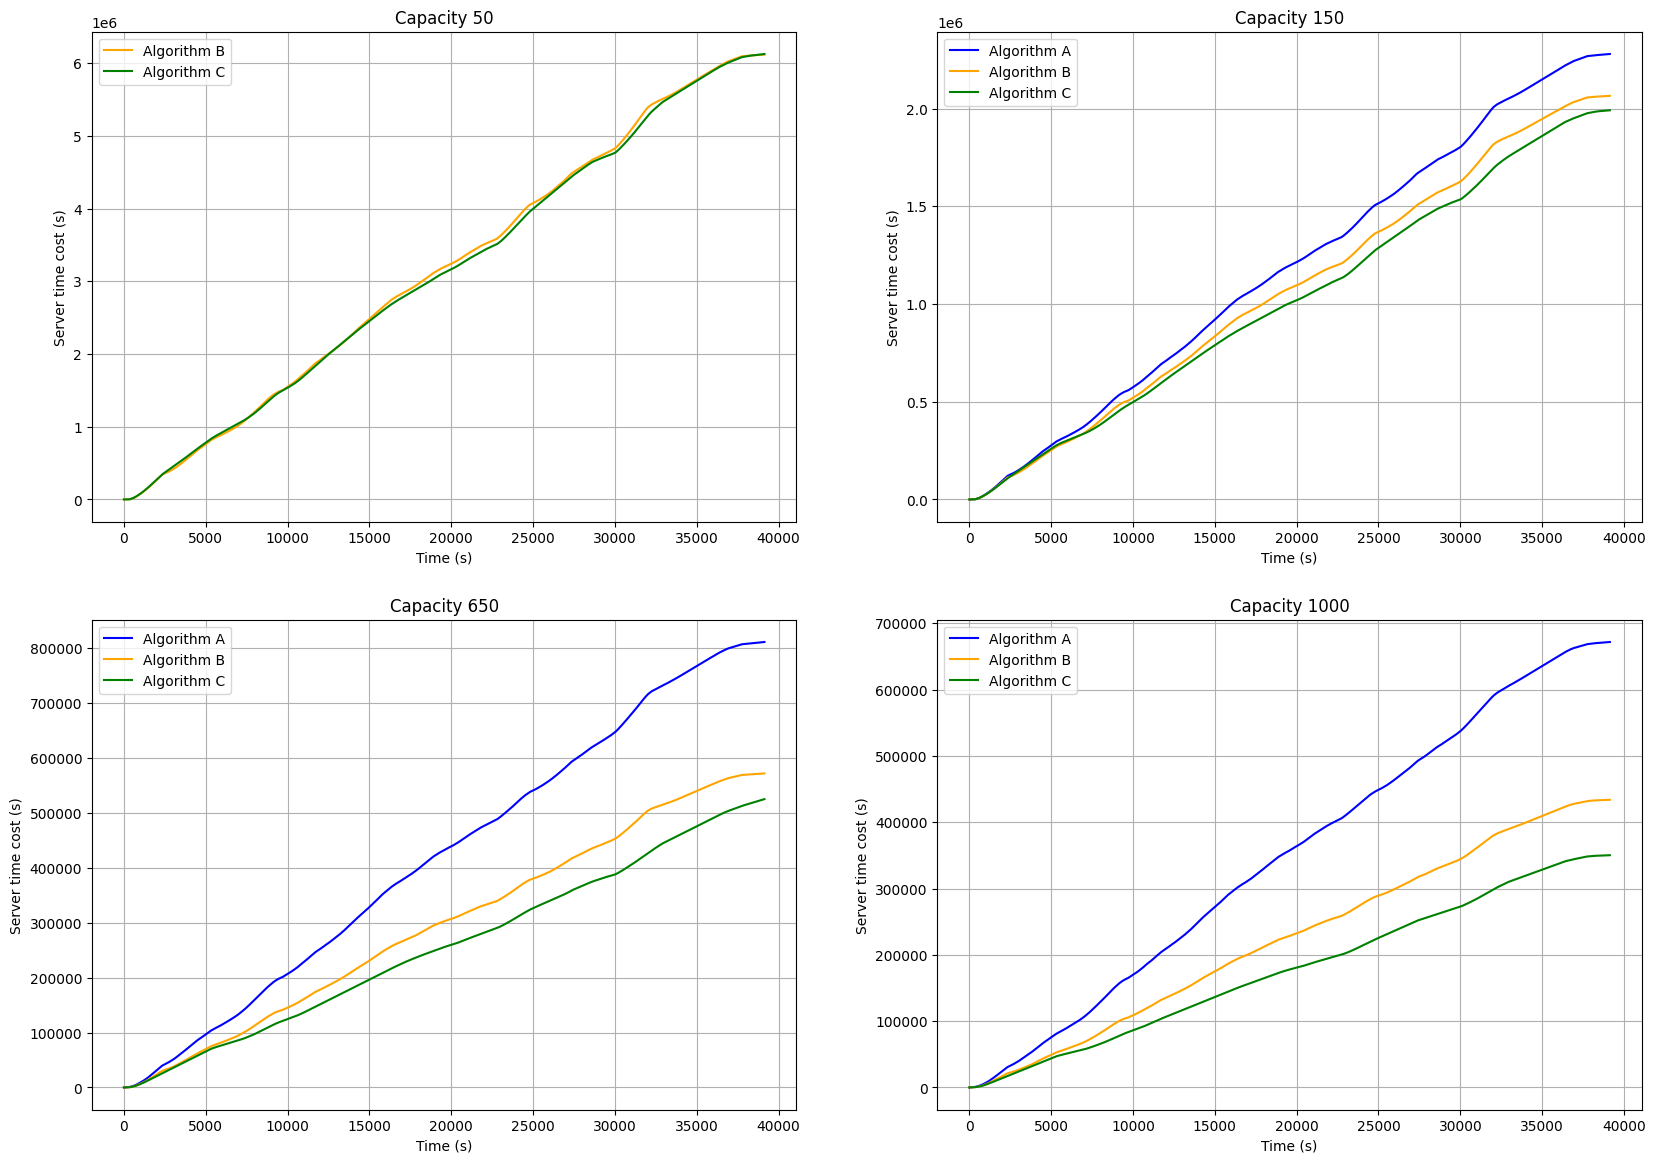

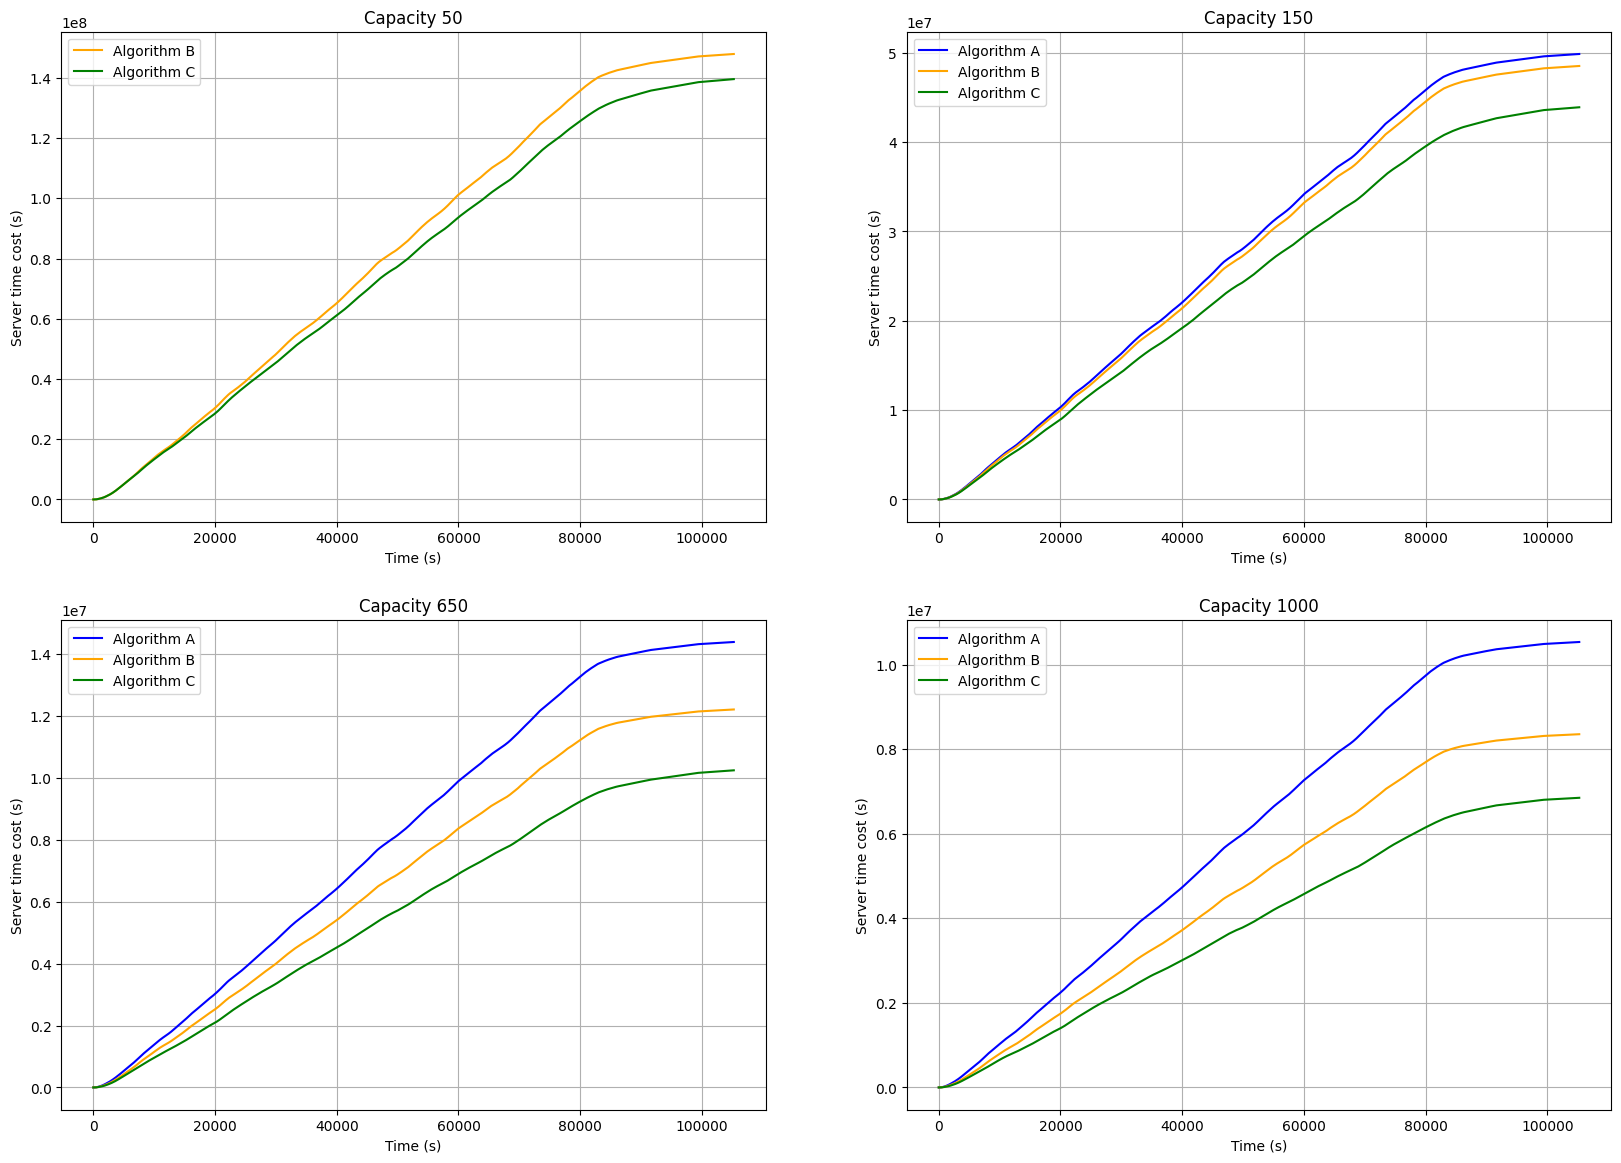

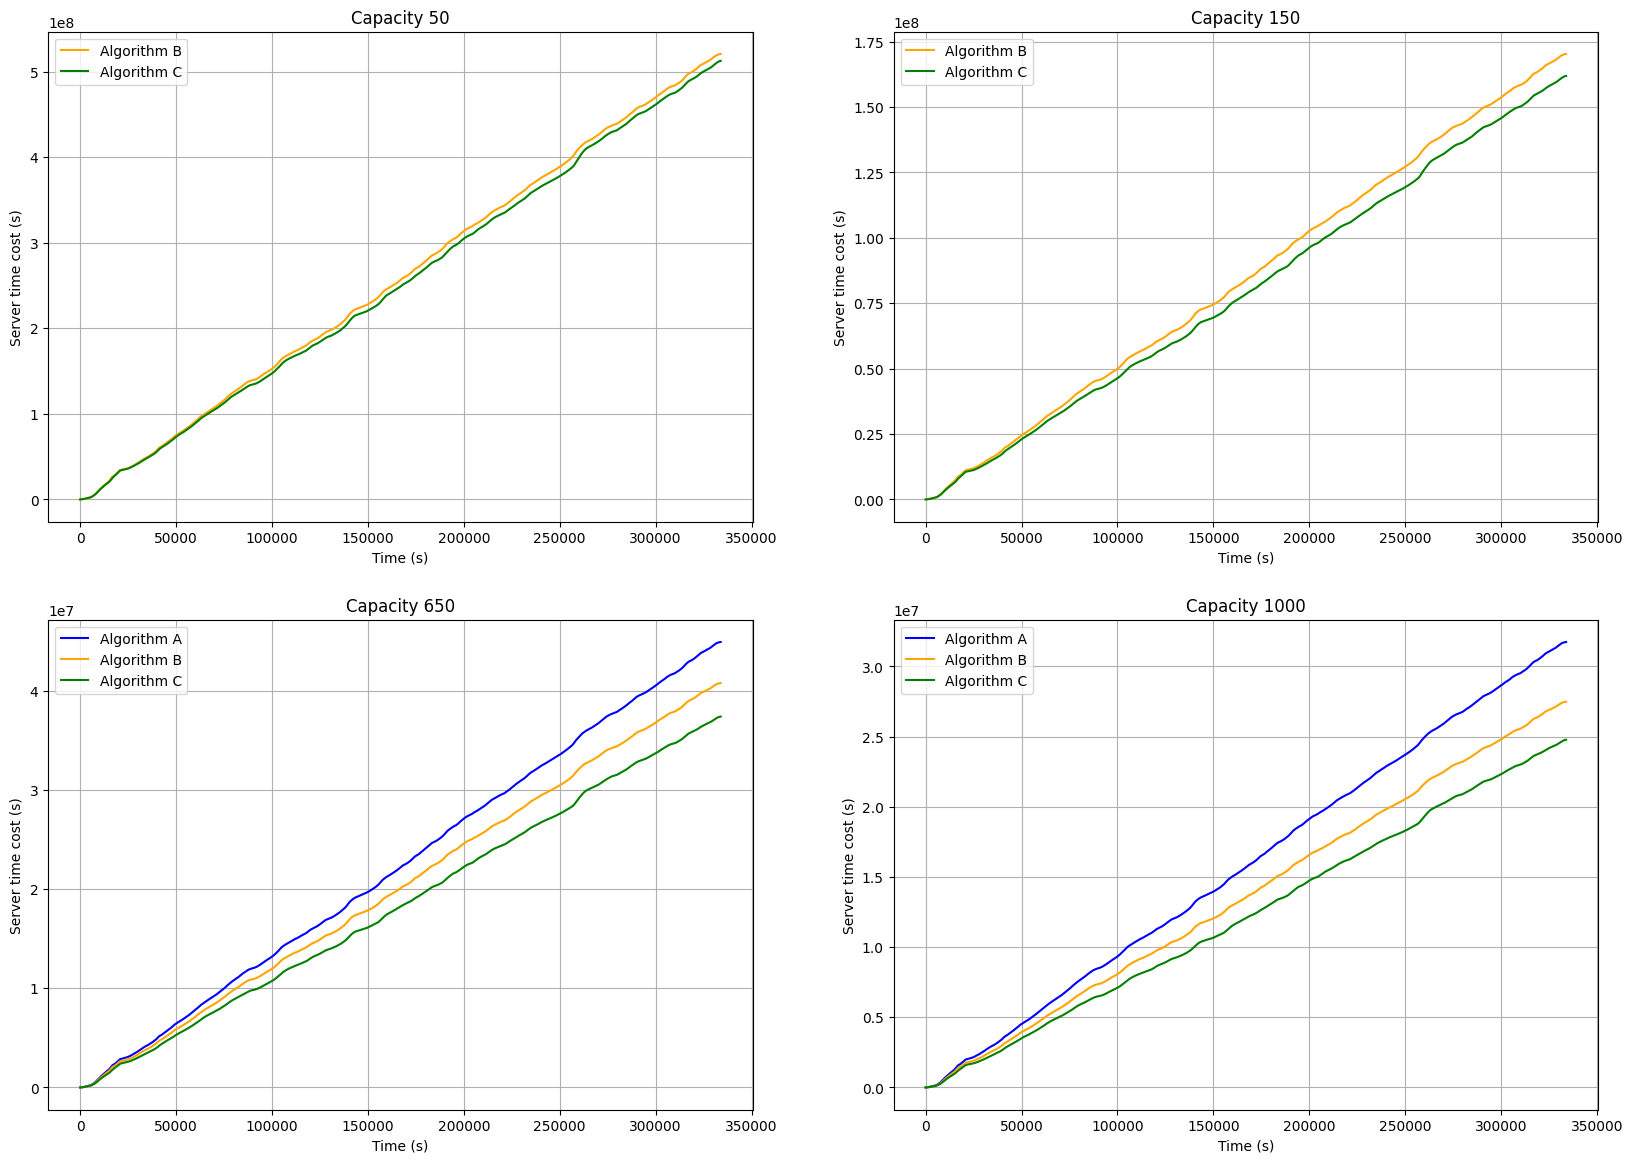

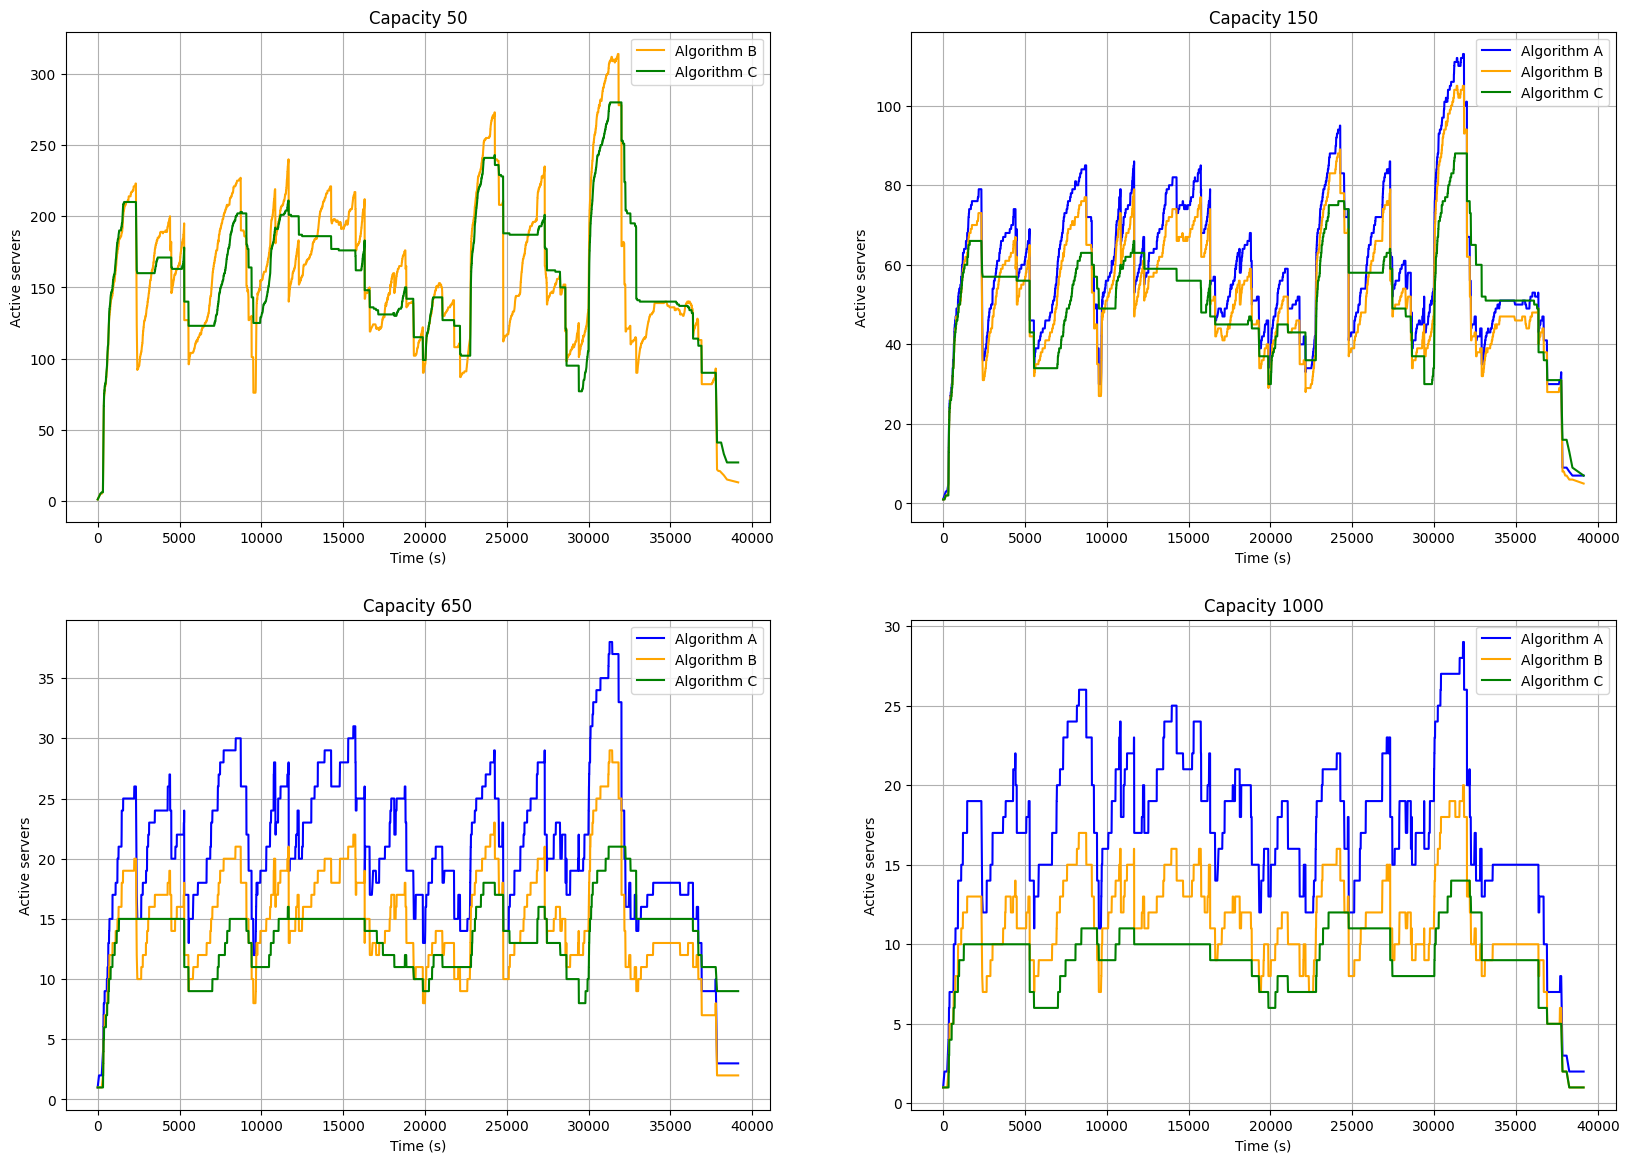

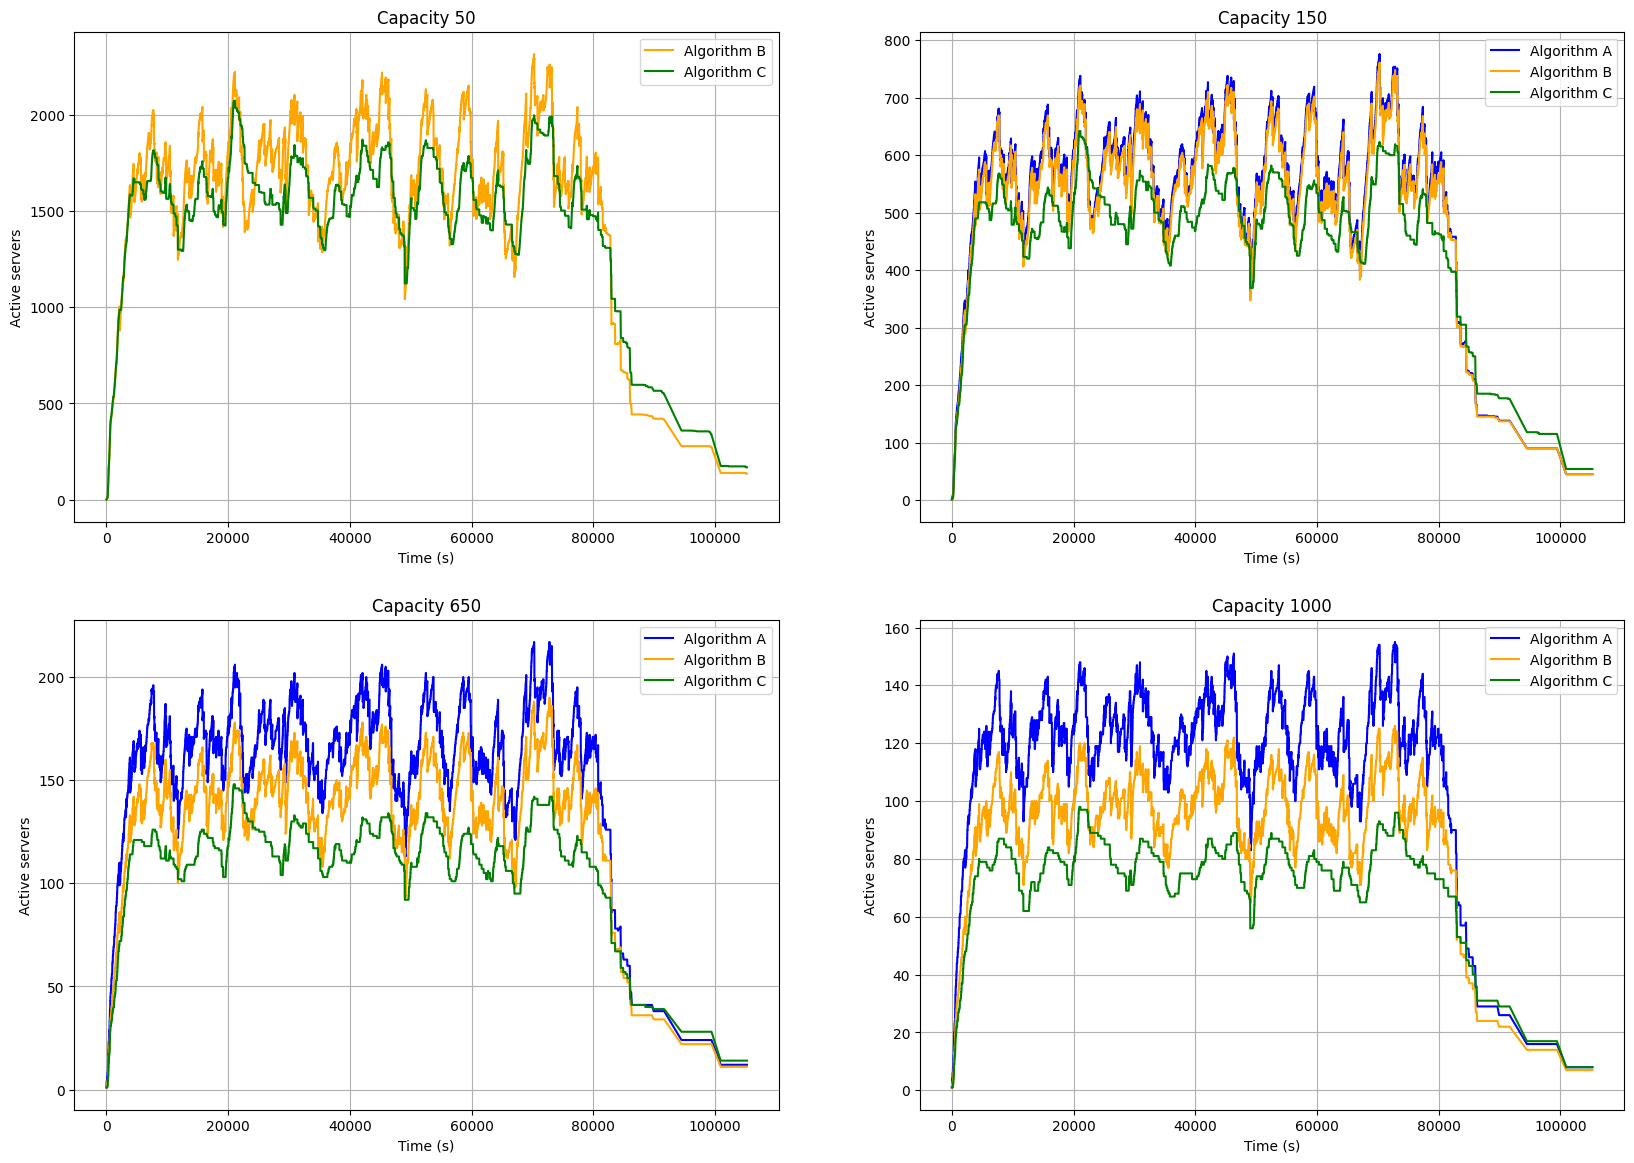

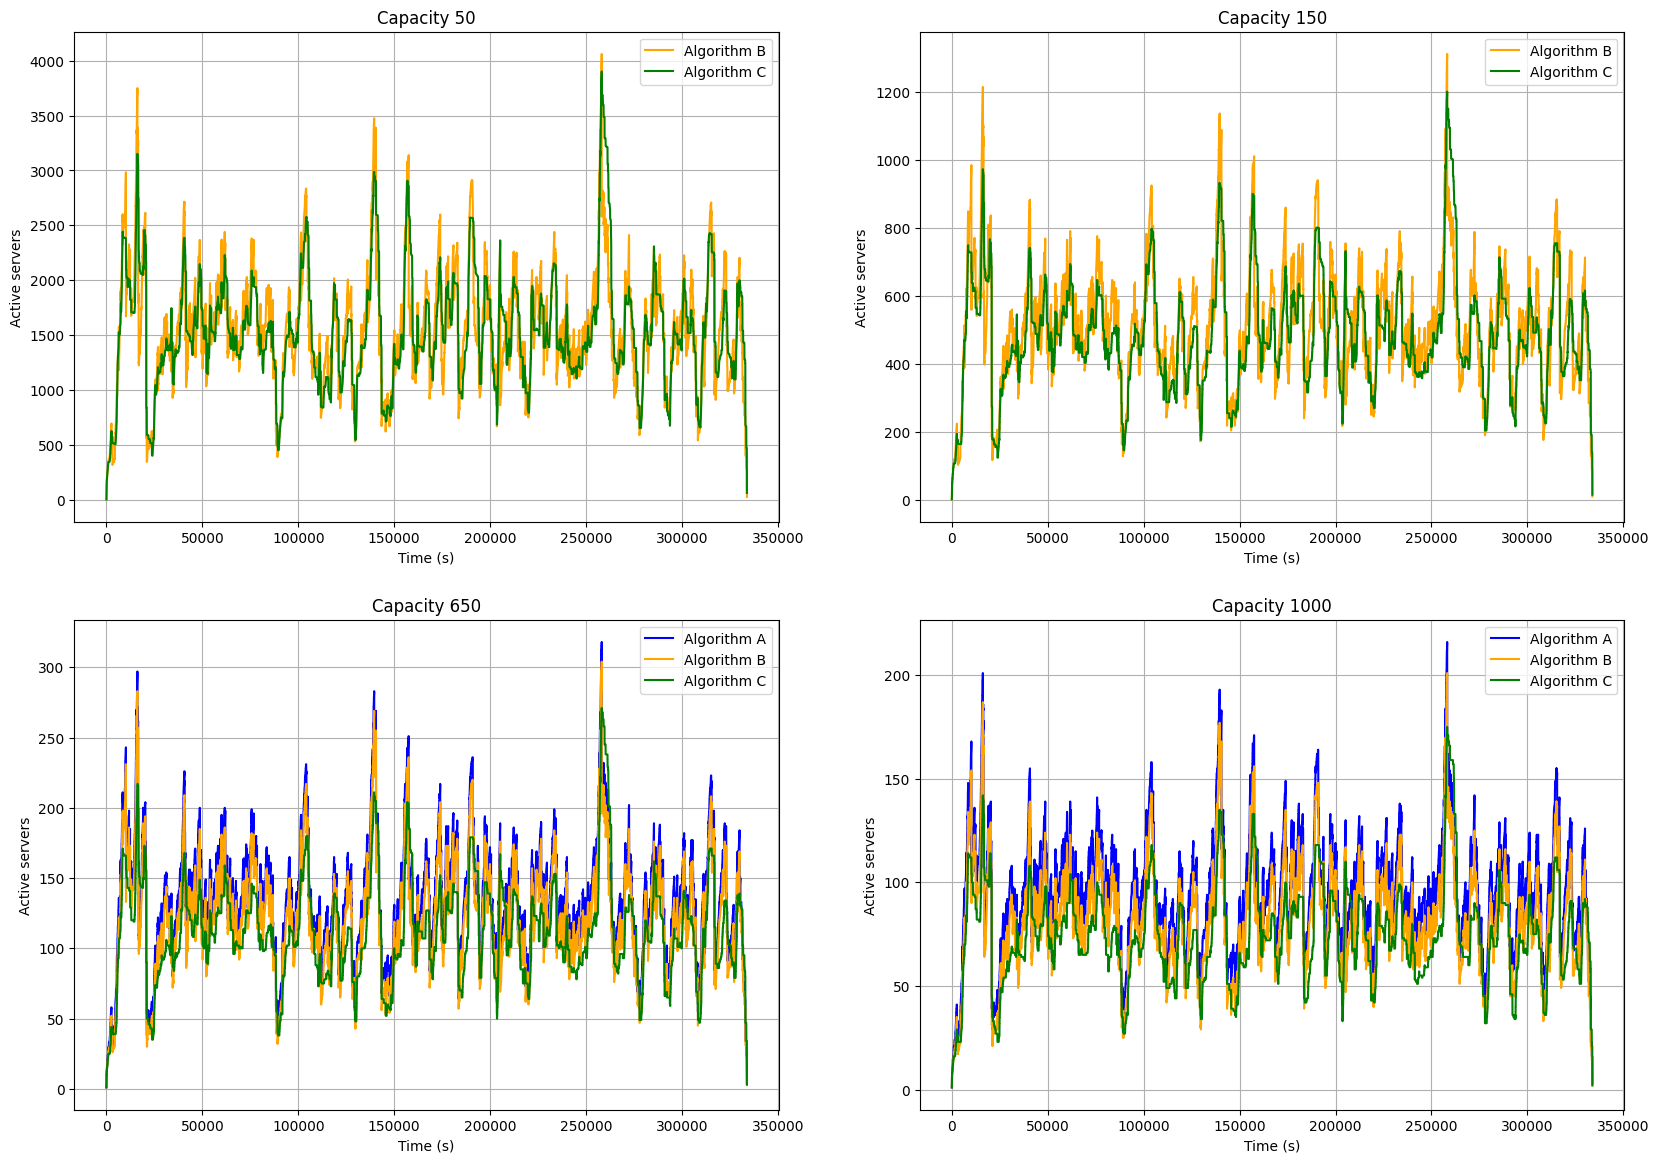

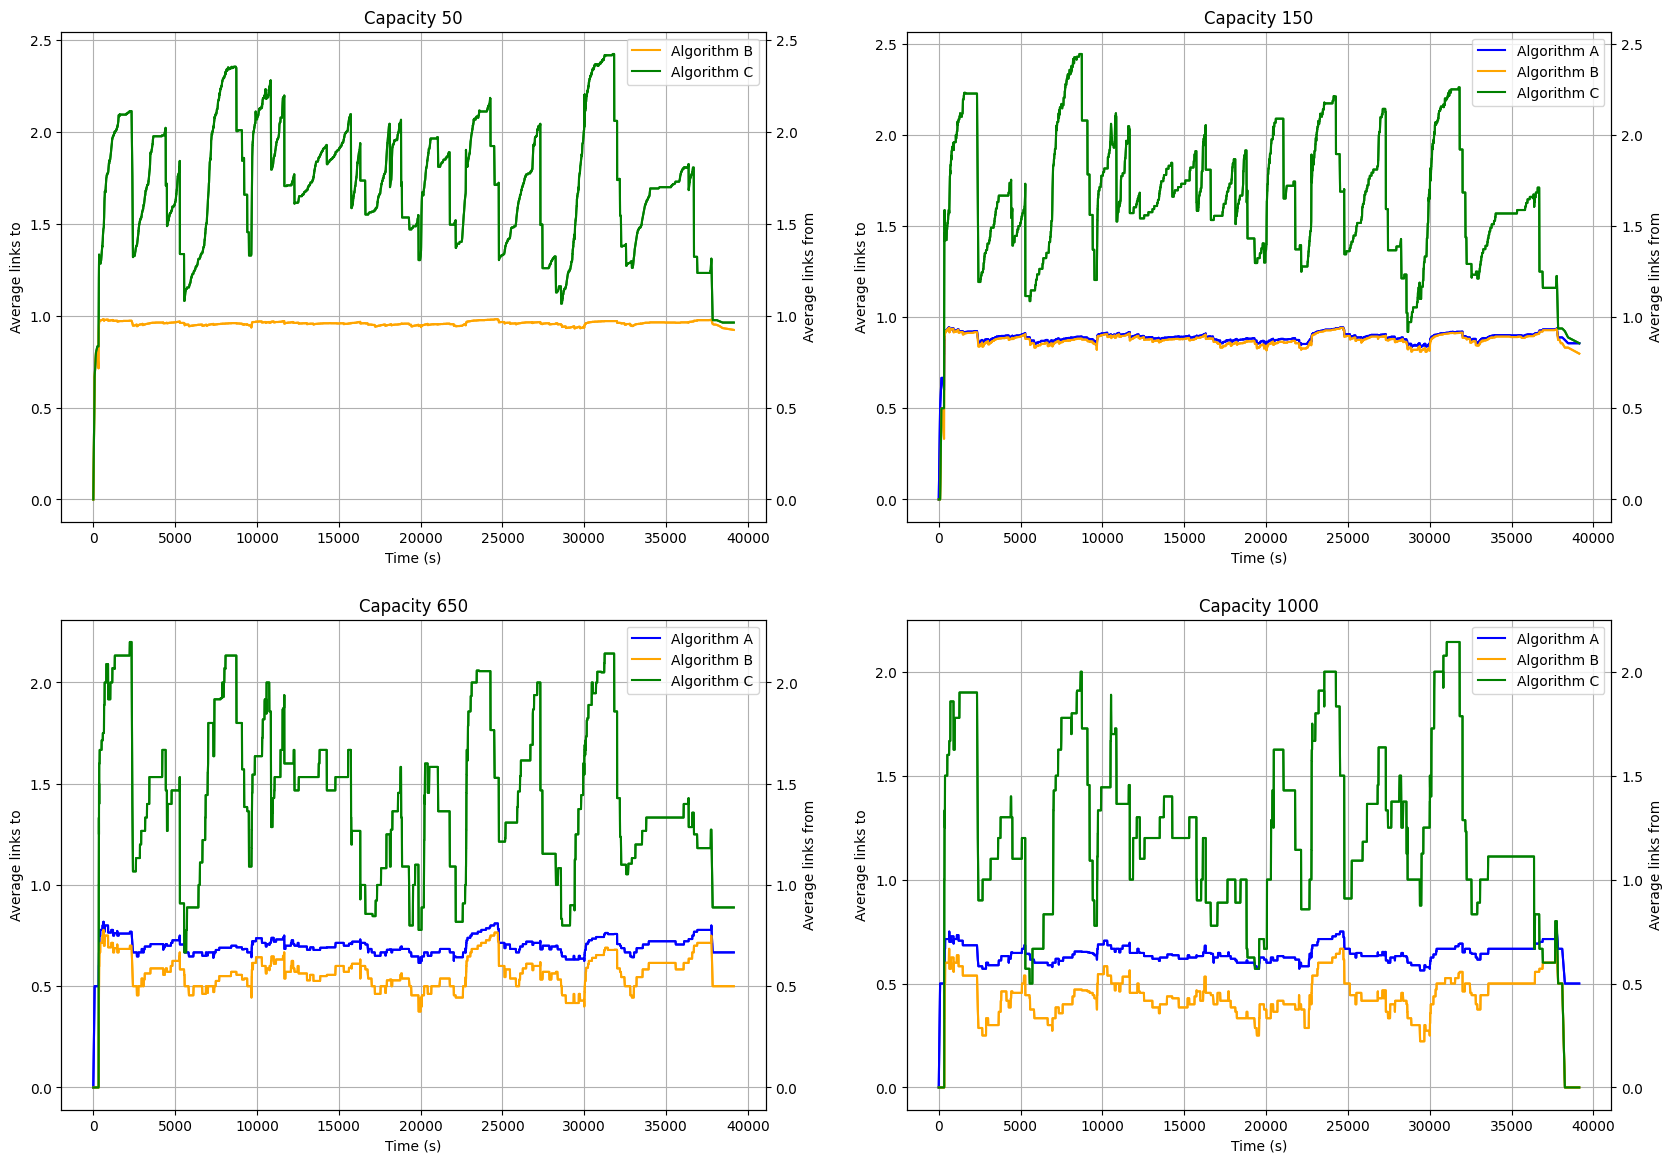

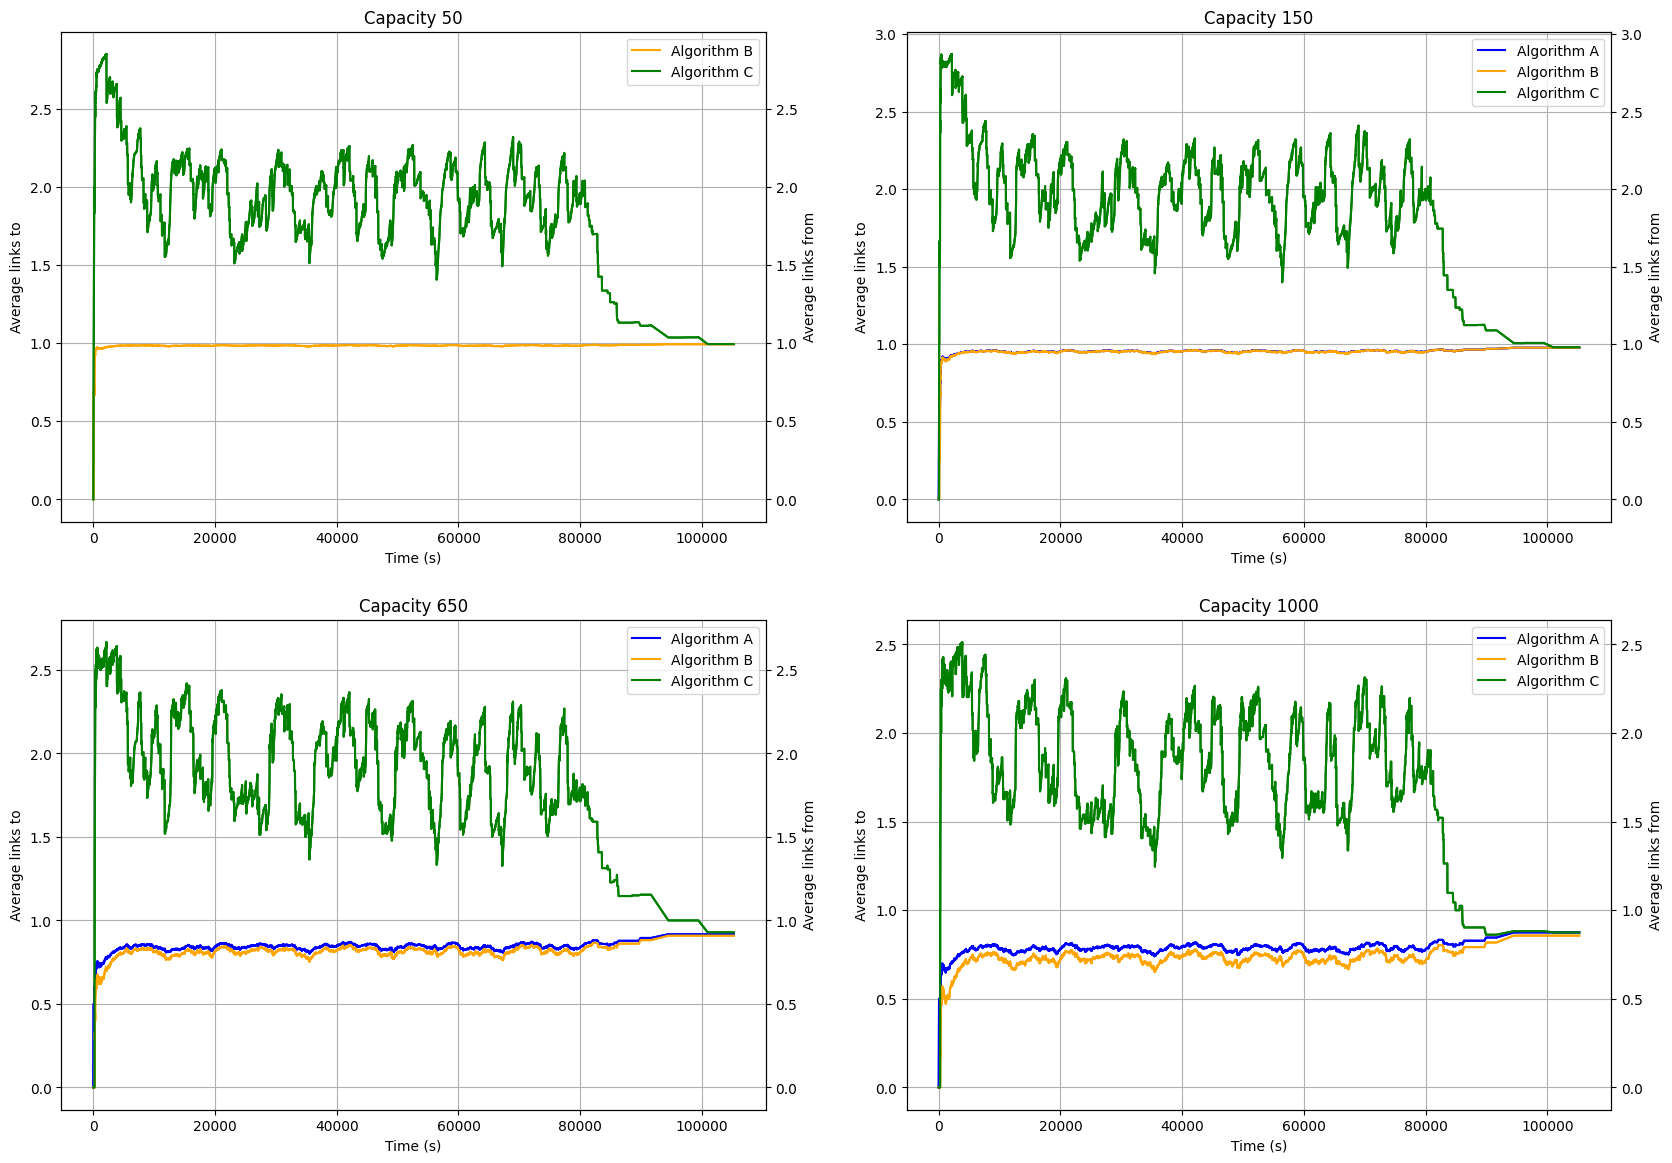

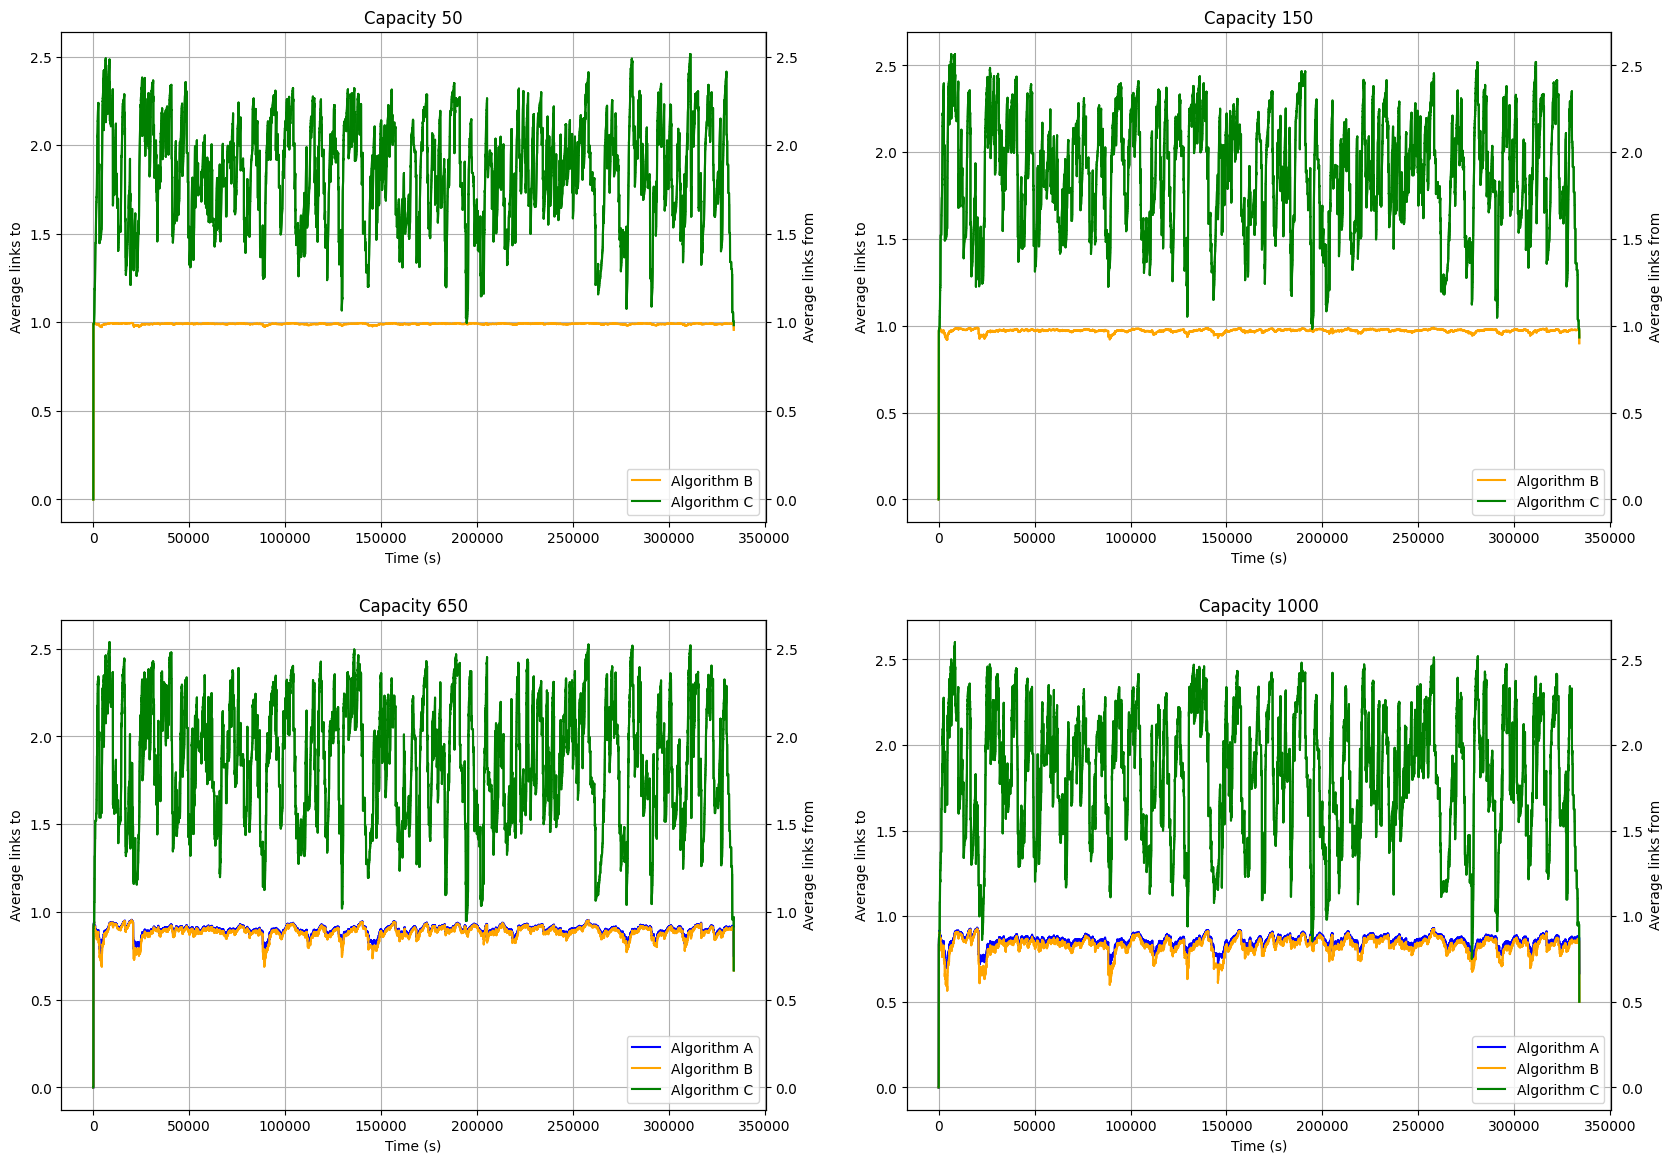

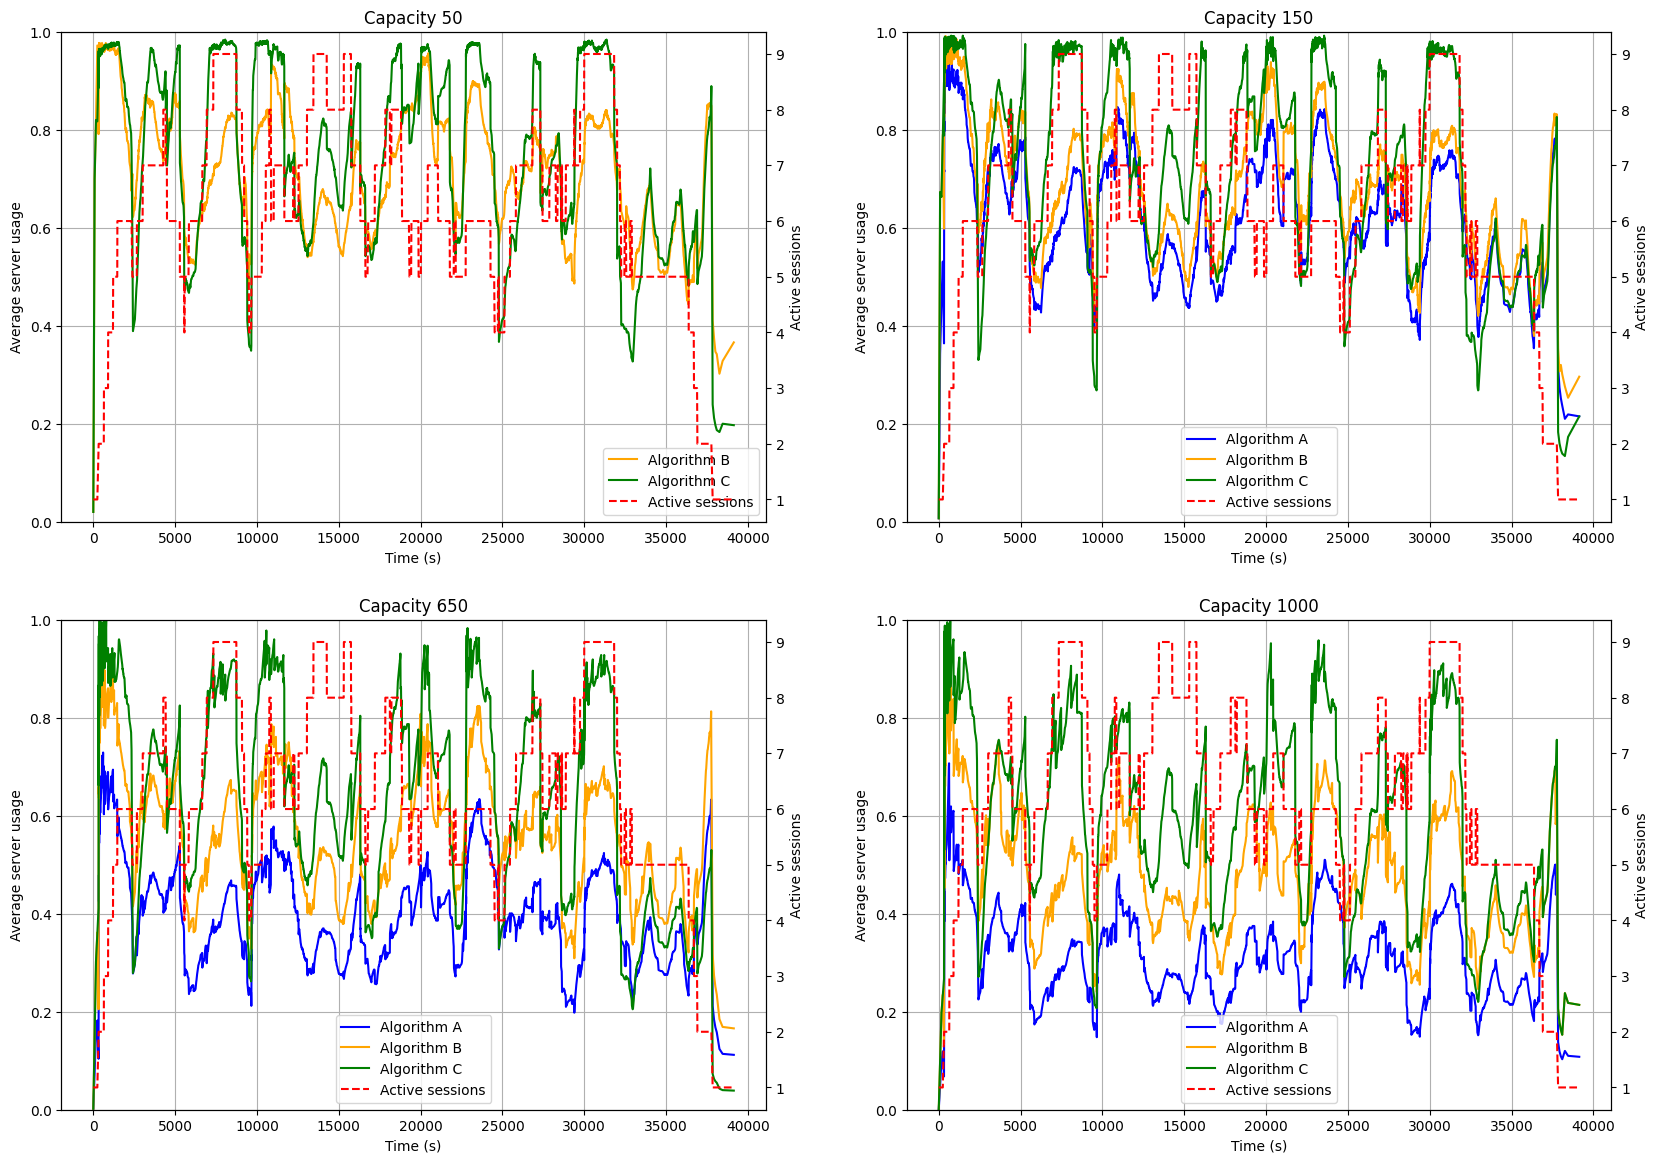

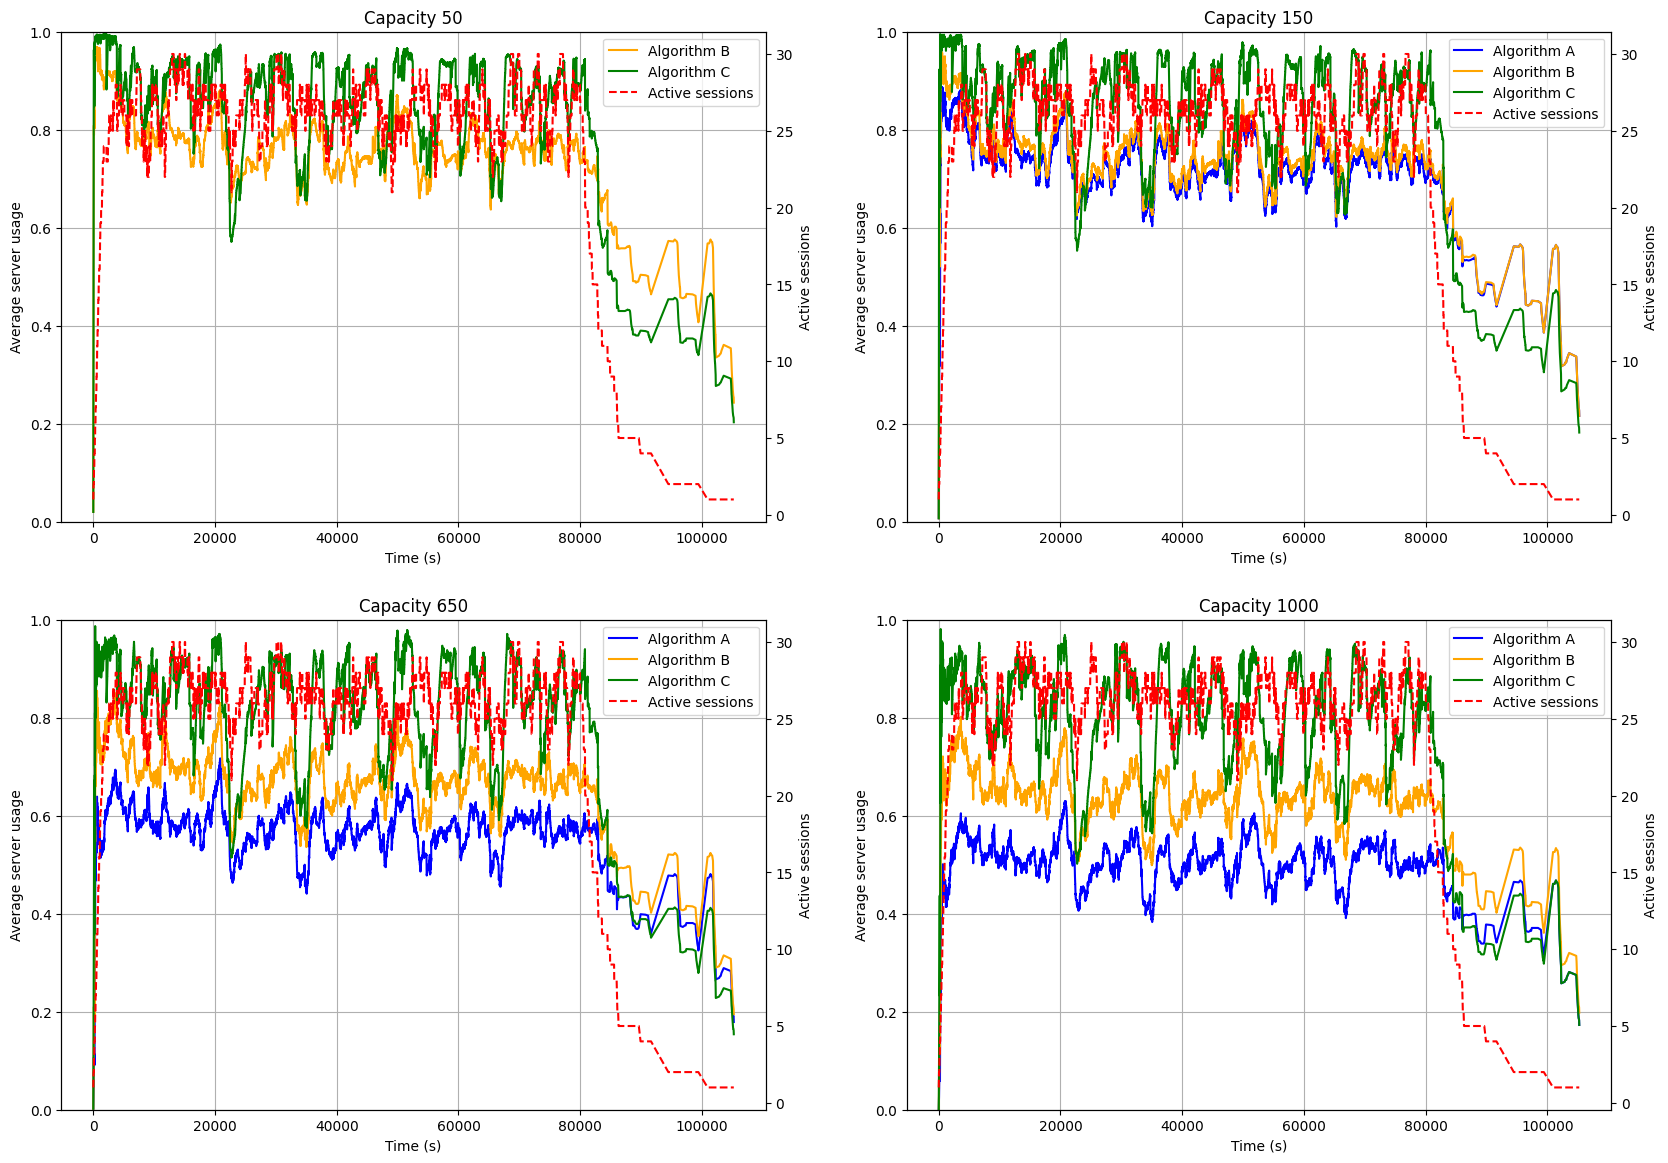

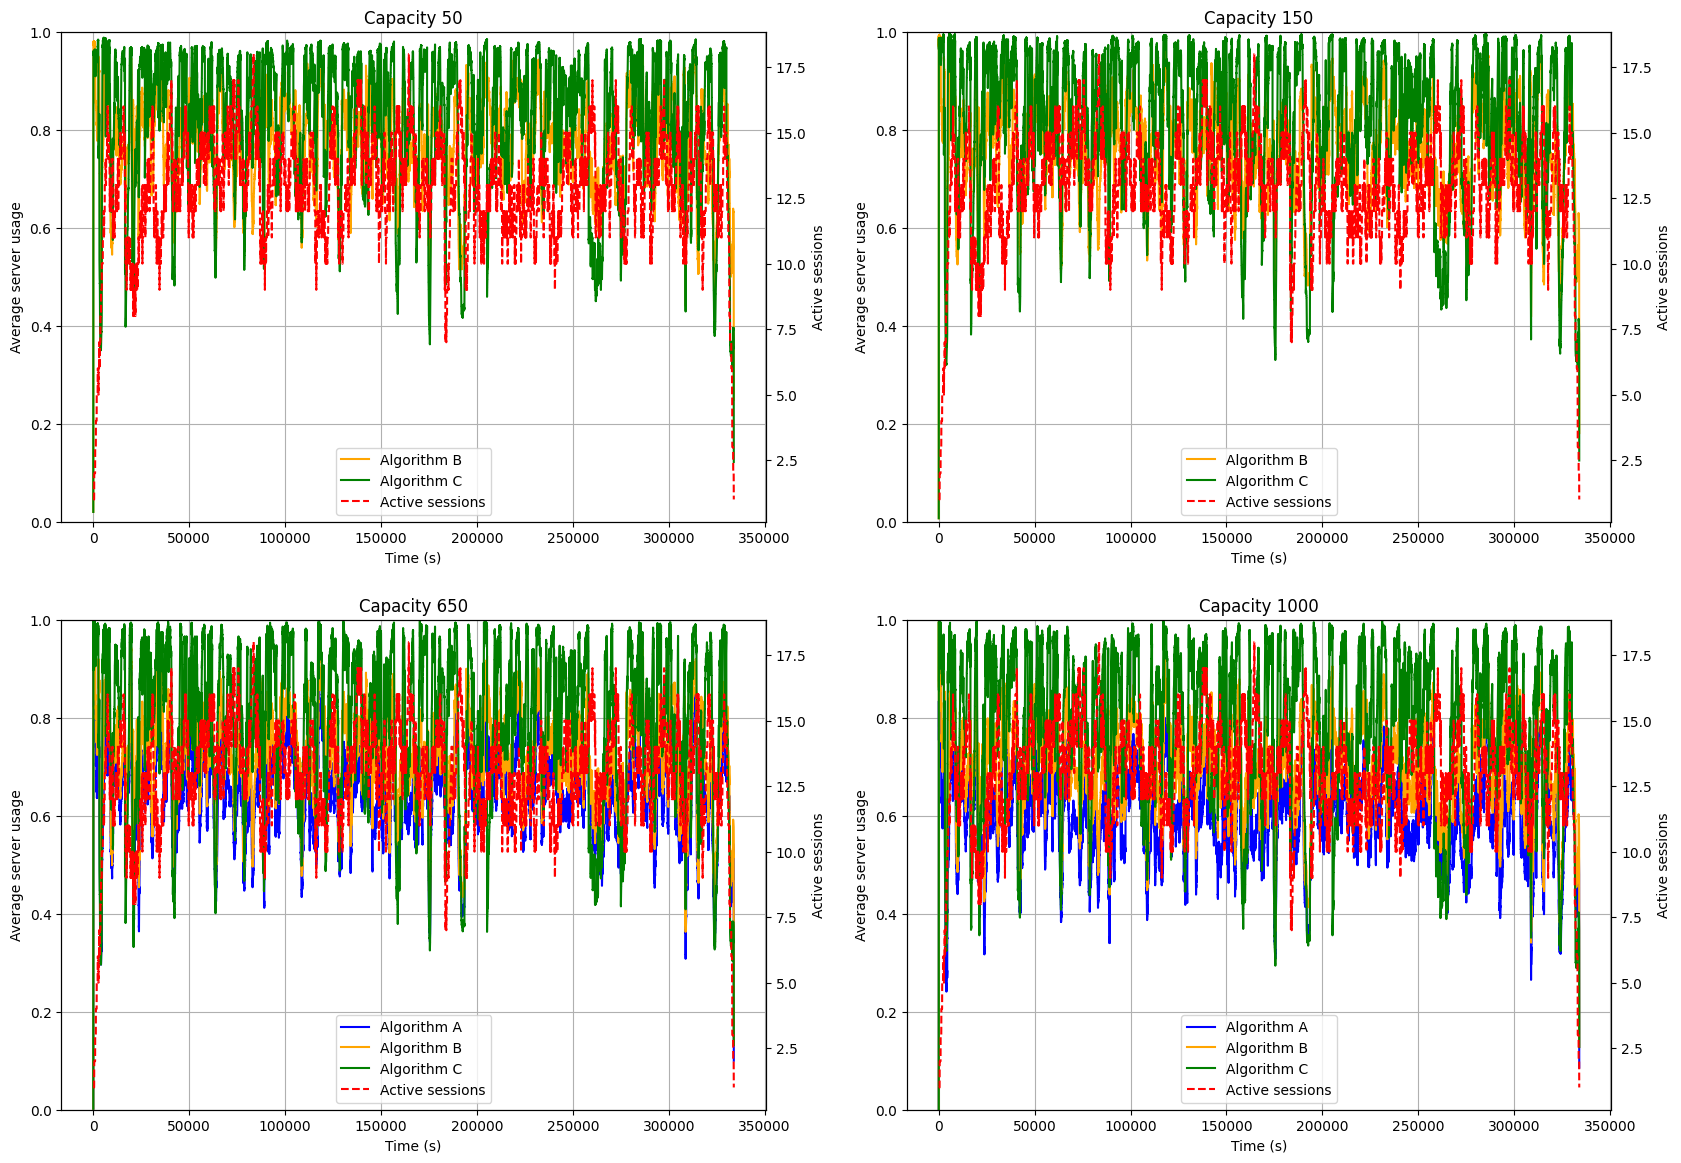

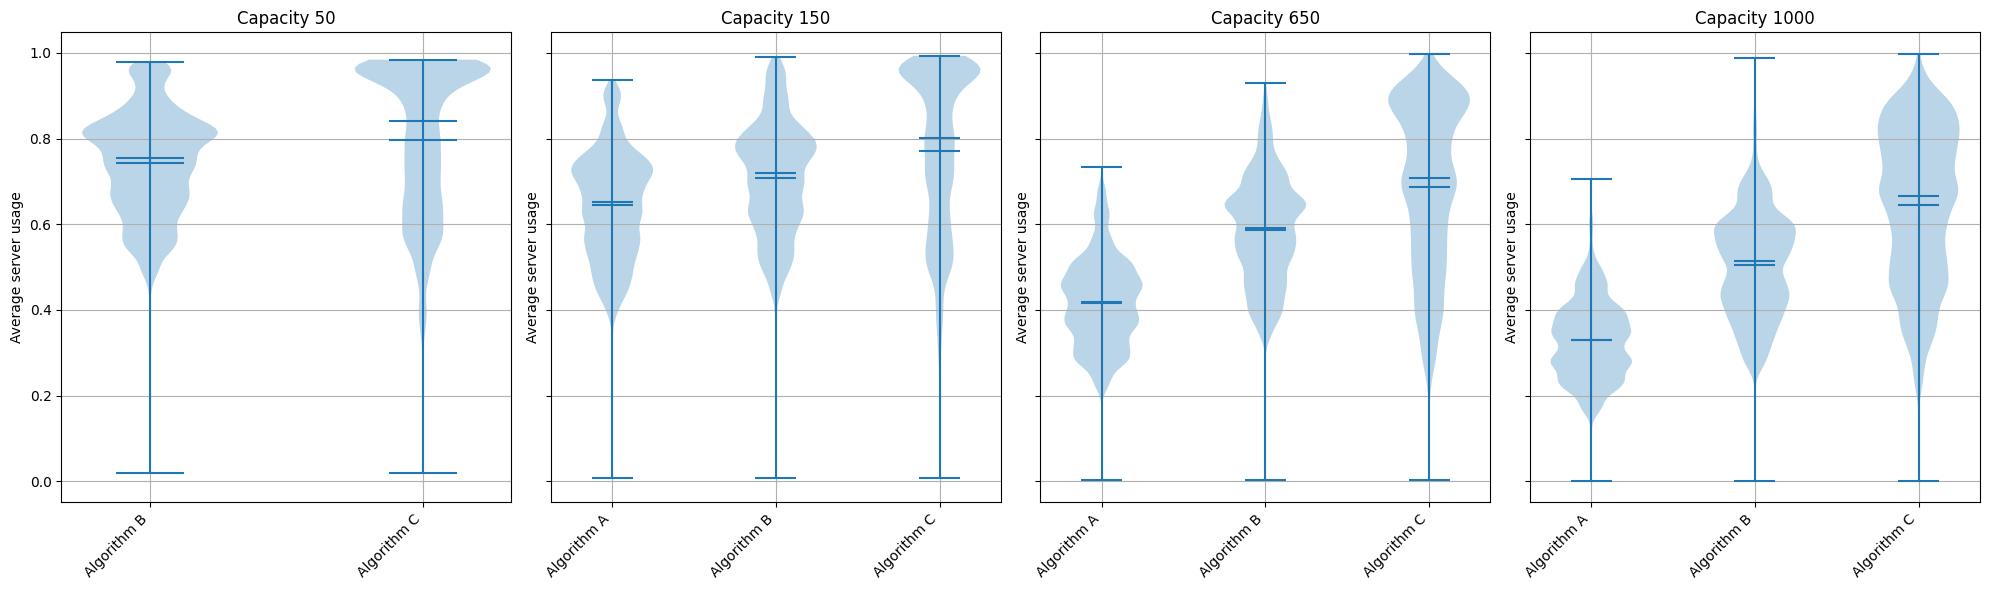

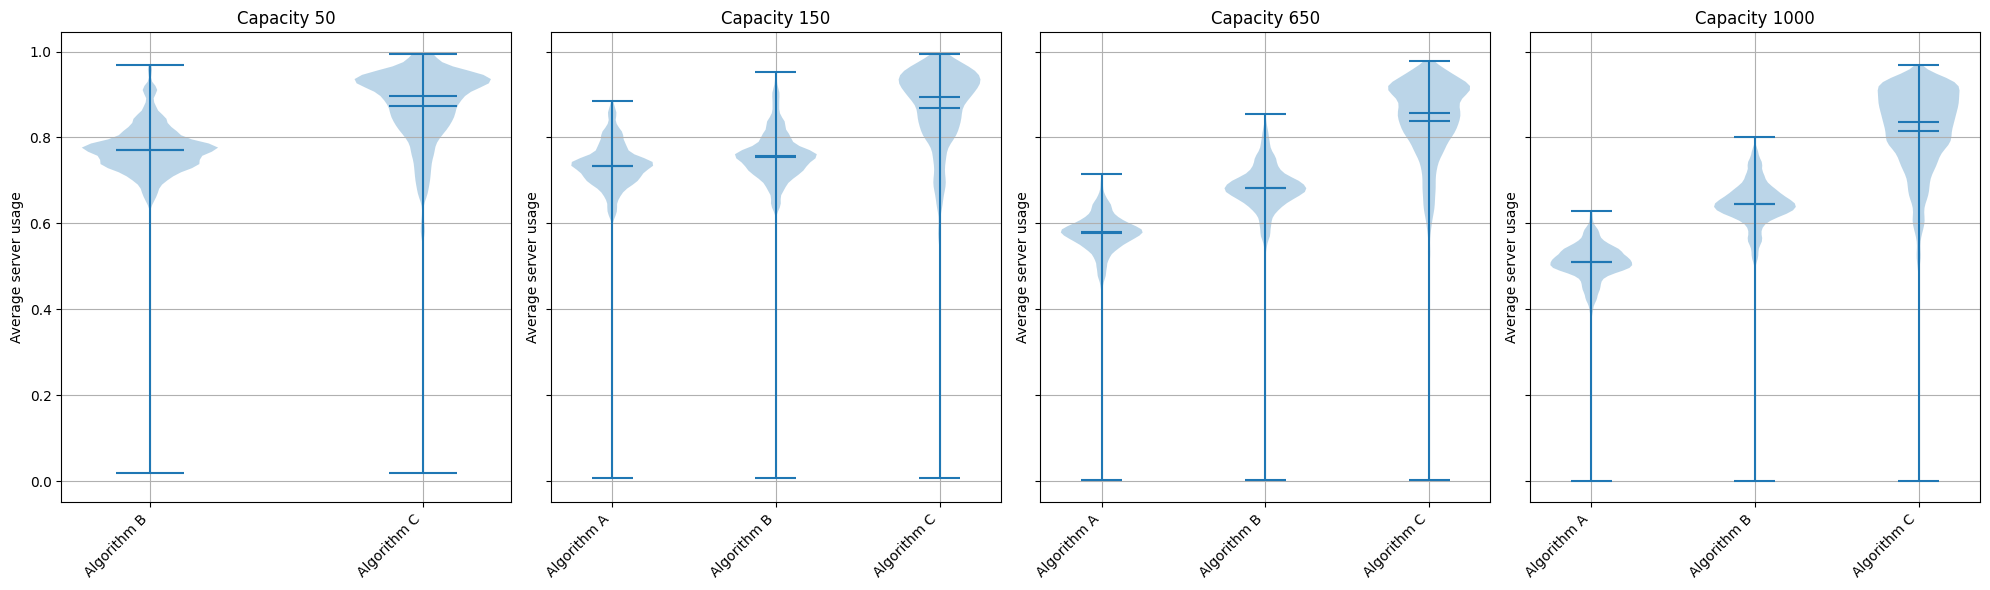

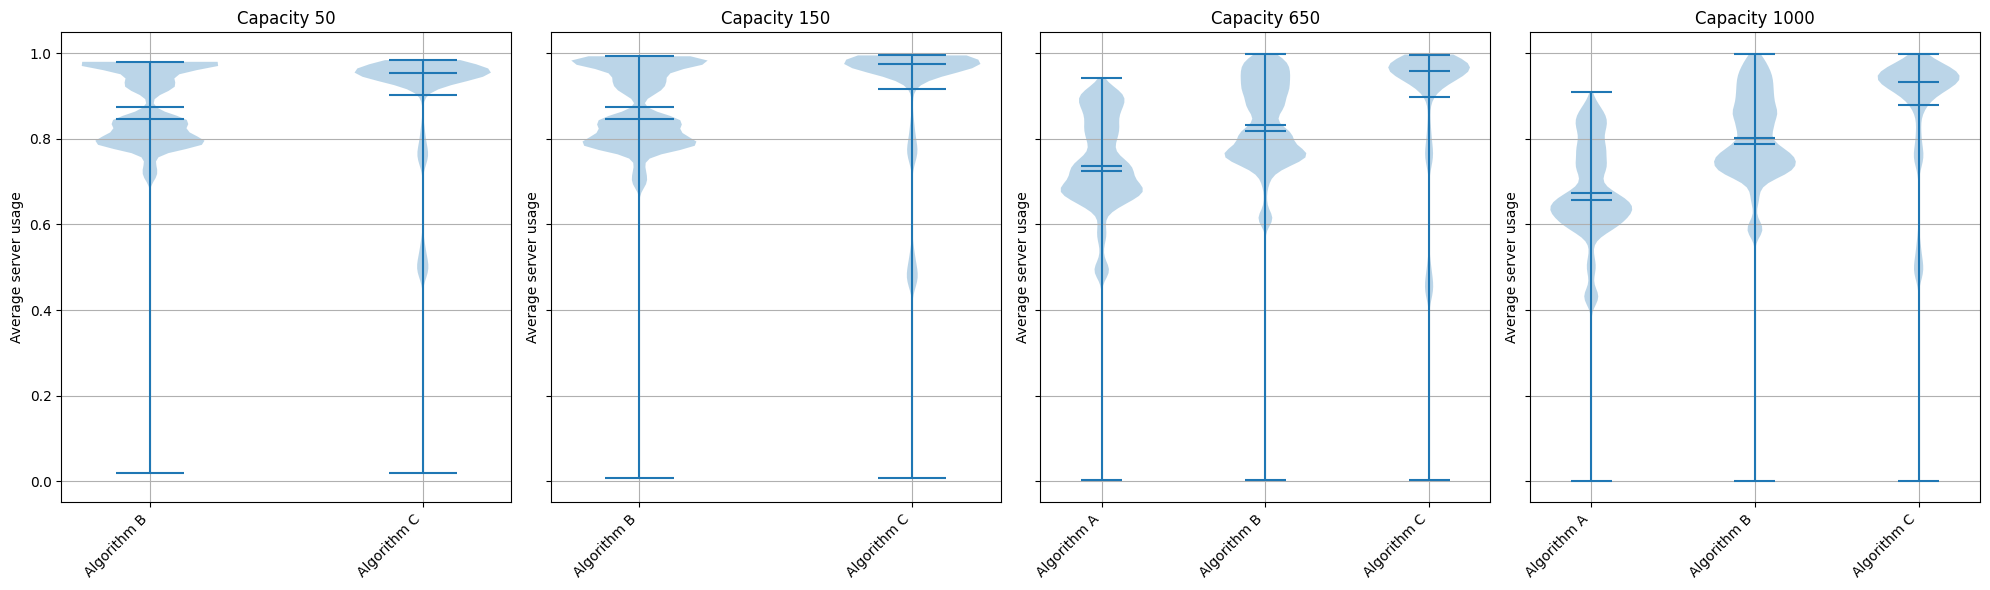

,Instance type,Server capacity,Max active servers A,Max active servers B,Max active servers C
0,small,50,0,314,280
1,small,150,113,105,88
2,small,650,38,29,21
3,small,1000,29,20,14
4,medium,50,0,2317,2074
5,medium,150,776,761,642
6,medium,650,217,190,148
7,medium,1000,155,126,98
8,big,50,0,4062,3902
9,big,150,0,1312,1201


In [14]:
# Execute memory-optimized analysis

# Create all plots using streaming processing
plot_figs = create_streaming_plots(sample_rate=100)

# Create violin plots for usage distribution
create_memory_efficient_violin_plots()

# Calculate maximum active servers
max_active_servers_df = calculate_max_active_servers_optimized()

# Save results to LaTeX
def to_latex_table(df, filename):
    """Save DataFrame as LaTeX table"""
    with open(filename, "w") as f:
        f.write(
            df.to_latex(
                index=False,
                float_format="%.0f",
                column_format="l" + "c" * (len(df.columns) - 1),
                escape=False,
            )
        )
display(max_active_servers_df)
to_latex_table(max_active_servers_df, "max_active_servers_optimized.tex")